In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

### Neuron without activation - Regression/Linear model

In [2]:
X_train = np.array([[1.0], [2.0]], dtype=np.float32)       
Y_train = np.array([[300.0], [500.0]], dtype=np.float32) 

In [5]:
# Convert to torch tensors
X_train_t = torch.from_numpy(X_train)
Y_train_t = torch.from_numpy(Y_train)

In [17]:
X_train_t, Y_train_t

(tensor([[1.],
         [2.]]),
 tensor([[300.],
         [500.]]))

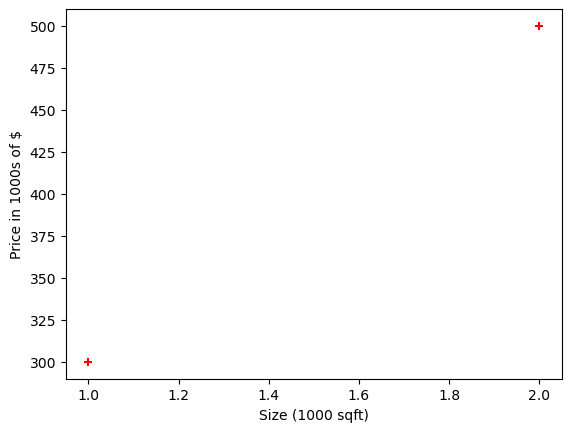

In [6]:
plt.scatter(X_train_t, Y_train_t, marker='+', c='r')
plt.ylabel('Price in 1000s of $')
plt.xlabel('Size (1000 sqft)')
plt.show()

In [8]:
# Define linear layer

linear_layer = nn.Linear(in_features=1, out_features=1, bias=True)

In [12]:
# Get initial weights
w = linear_layer.weight
b = linear_layer.bias
w, b

(Parameter containing:
 tensor([[0.6157]], requires_grad=True),
 Parameter containing:
 tensor([0.8297], requires_grad=True))

In [13]:
# Forward pass on one example

a1 = linear_layer(X_train_t[0].reshape(1, 1))
a1

tensor([[1.4454]], grad_fn=<AddmmBackward0>)

In [18]:
# Manually set weights

set_w = np.array([[200.0]], dtype=np.float32)
set_b = np.array([100.0], dtype=np.float32)

with torch.no_grad():
    linear_layer.weight.copy_(torch.from_numpy(set_w))
    linear_layer.bias.copy_(torch.from_numpy(set_b))

In [19]:
print("Updated weights:")
print(linear_layer.weight.detach().numpy(),
      linear_layer.bias.detach().numpy())

Updated weights:
[[200.]] [100.]


In [21]:
a1 = linear_layer(X_train_t[0].reshape(1, 1))
a1

tensor([[300.]], grad_fn=<AddmmBackward0>)

In [22]:
prediction_torch = linear_layer(X_train_t).detach().numpy()
prediction_np = np.dot(X_train, set_w) + set_b

In [23]:
print("Torch prediction:\n", prediction_torch)
print("Numpy prediction:\n", prediction_np)

Torch prediction:
 [[300.]
 [500.]]
Numpy prediction:
 [[300.]
 [500.]]


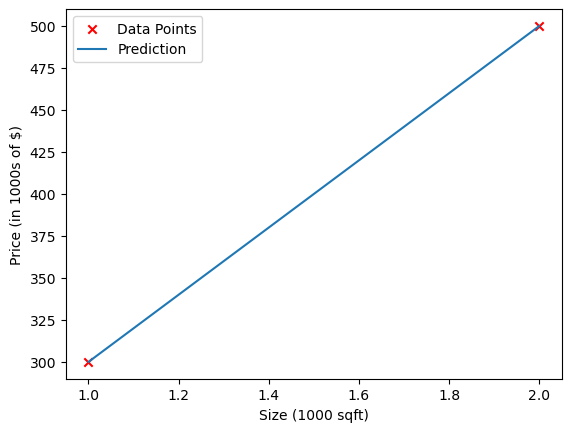

In [24]:
plt.scatter(X_train, Y_train, marker='x', c='r', label='Data Points')
plt.plot(X_train, prediction_torch, label='Prediction')
plt.legend()
plt.ylabel('Price (in 1000s of $)')
plt.xlabel('Size (1000 sqft)')
plt.show()


# Neuron with sigmoid activation

In [26]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [25]:
X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)  # 2-D Matrix
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)  # 2-D Matrix

In [27]:
X_train_t = torch.from_numpy(X_train)
Y_train_t = torch.from_numpy(Y_train)

In [28]:
X_train_t

tensor([[0.],
        [1.],
        [2.],
        [3.],
        [4.],
        [5.]])

In [29]:
Y_train_t

tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.]])

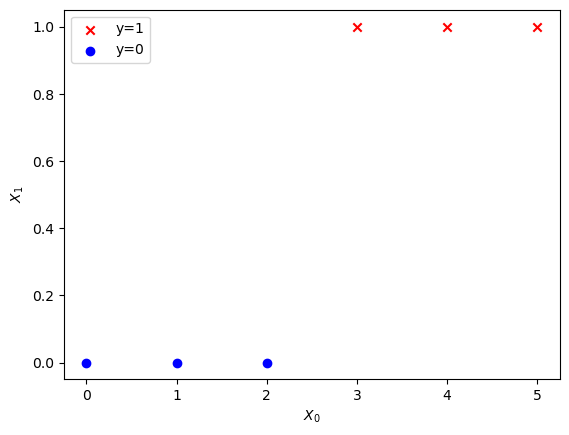

In [31]:
pos = Y_train_t == 1
neg = Y_train_t == 0

plt.scatter(X_train_t[pos], Y_train_t[pos], marker='x', c='red', label='y=1')
plt.scatter(X_train_t[neg], Y_train_t[neg], marker='o', c='blue', label='y=0')
plt.xlabel('$X_0$')
plt.ylabel('$X_1$')
plt.legend()
plt.show()

In [33]:
model = nn.Sequential(
    nn.Linear(1, 1), # Dense (1, input_dim=1)
    nn.Sigmoid() # activation='Sigmoid'
)

In [34]:
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): Sigmoid()
)


In [42]:
logistic_layer = model(X_train_t)

In [43]:
logistic_layer

tensor([[0.2724],
        [0.2334],
        [0.1986],
        [0.1677],
        [0.1409],
        [0.1177]], grad_fn=<SigmoidBackward0>)

# PyTorch Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

In [2]:
X = np.array([[185.32,  12.69],
       [259.92,  11.87],
       [231.01,  14.41],
       [175.37,  11.72],
       [187.12,  14.13],
       [225.91,  12.1 ],
       [208.41,  14.18],
       [207.08,  14.03],
       [280.6 ,  14.23],
       [202.87,  12.25],
       [196.7 ,  13.54],
       [270.31,  14.6 ],
       [192.95,  15.2 ],
       [213.57,  14.28],
       [164.47,  11.92],
       [177.26,  15.04],
       [241.77,  14.9 ],
       [237.  ,  13.13],
       [219.74,  13.87],
       [266.39,  13.25],
       [270.45,  13.95],
       [261.96,  13.49],
       [243.49,  12.86],
       [220.58,  12.36],
       [163.59,  11.65],
       [244.76,  13.33],
       [271.19,  14.84],
       [201.99,  15.39],
       [229.93,  14.56],
       [204.97,  12.28],
       [173.19,  12.22],
       [231.51,  11.95],
       [152.69,  14.83],
       [163.42,  13.3 ],
       [215.95,  13.98],
       [218.04,  15.25],
       [251.3 ,  13.8 ],
       [233.33,  13.53],
       [280.24,  12.41],
       [243.02,  13.72],
       [155.67,  12.68],
       [275.17,  14.64],
       [151.73,  12.69],
       [151.32,  14.81],
       [164.9 ,  11.73],
       [282.55,  13.28],
       [192.98,  11.7 ],
       [202.6 ,  12.96],
       [220.67,  11.53],
       [169.97,  12.34],
       [209.47,  12.71],
       [232.8 ,  12.64],
       [272.8 ,  15.35],
       [158.02,  12.34],
       [226.01,  14.58],
       [158.64,  12.24],
       [211.66,  14.17],
       [271.95,  14.97],
       [257.16,  11.71],
       [281.85,  13.96],
       [161.63,  12.52],
       [233.8 ,  13.04],
       [210.29,  14.72],
       [261.24,  13.69],
       [256.98,  13.12],
       [281.56,  13.92],
       [280.64,  11.68],
       [269.16,  13.74],
       [246.34,  12.27],
       [224.07,  12.66],
       [164.24,  11.51],
       [272.42,  14.18],
       [177.68,  12.53],
       [212.86,  14.77],
       [165.88,  15.37],
       [277.43,  12.48],
       [236.51,  12.94],
       [244.14,  11.85],
       [213.45,  13.85],
       [234.57,  14.27],
       [270.34,  12.47],
       [170.68,  13.06],
       [226.79,  15.34],
       [245.92,  14.45],
       [281.32,  12.57],
       [185.03,  13.19],
       [189.88,  14.1 ],
       [278.48,  12.11],
       [219.92,  14.21],
       [216.58,  15.15],
       [249.48,  15.03],
       [165.09,  12.28],
       [158.87,  14.82],
       [279.98,  11.56],
       [256.55,  14.41],
       [272.61,  12.58],
       [246.49,  12.45],
       [160.26,  14.48],
       [155.7 ,  14.3 ],
       [188.27,  13.45],
       [270.36,  12.47],
       [213.22,  12.92],
       [175.7 ,  13.39],
       [174.52,  14.7 ],
       [233.  ,  12.63],
       [281.37,  12.88],
       [240.62,  14.43],
       [185.81,  11.55],
       [270.5 ,  15.33],
       [172.98,  12.11],
       [208.41,  13.89],
       [283.51,  15.35],
       [283.36,  12.48],
       [230.85,  13.24],
       [181.24,  11.76],
       [172.78,  12.93],
       [161.88,  12.1 ],
       [156.03,  13.99],
       [216.52,  12.47],
       [221.06,  13.2 ],
       [238.99,  15.23],
       [197.69,  14.08],
       [179.55,  15.26],
       [233.39,  12.13],
       [184.7 ,  12.14],
       [174.18,  12.73],
       [261.11,  13.33],
       [187.42,  13.18],
       [186.1 ,  14.43],
       [157.94,  12.66],
       [193.64,  12.23],
       [249.65,  12.22],
       [190.56,  11.73],
       [252.  ,  12.96],
       [238.55,  12.37],
       [152.94,  12.79],
       [255.17,  14.85],
       [197.09,  14.89],
       [156.8 ,  13.59],
       [184.75,  13.26],
       [179.92,  15.07],
       [190.79,  15.28],
       [164.73,  13.22],
       [209.87,  14.34],
       [196.58,  13.47],
       [159.51,  12.74],
       [247.87,  11.92],
       [212.44,  12.45],
       [172.34,  11.99],
       [259.87,  14.25],
       [201.23,  13.07],
       [248.34,  13.92],
       [273.66,  15.18],
       [215.09,  14.14],
       [223.53,  12.74],
       [211.22,  14.38],
       [224.61,  14.03],
       [215.75,  15.31],
       [254.82,  12.02],
       [259.9 ,  15.17],
       [260.25,  12.87],
       [199.67,  12.47],
       [157.52,  13.39],
       [264.81,  14.58],
       [239.4 ,  14.89],
       [238.98,  12.39],
       [258.43,  12.97],
       [270.16,  12.81],
       [162.41,  14.42],
       [164.53,  14.98],
       [205.61,  14.62],
       [157.1 ,  13.68],
       [241.38,  12.02],
       [232.13,  12.07],
       [191.04,  12.96],
       [233.64,  12.02],
       [174.95,  14.63],
       [246.64,  13.32],
       [188.07,  14.27],
       [213.16,  12.75],
       [268.08,  12.31],
       [258.58,  13.97],
       [237.21,  14.23],
       [251.02,  15.02],
       [274.28,  12.52],
       [172.12,  15.09],
       [177.52,  12.39],
       [258.71,  15.36],
       [264.01,  13.57],
       [200.71,  15.45],
       [249.37,  14.02],
       [151.5 ,  12.28],
       [151.82,  15.13],
       [181.92,  12.18],
       [228.65,  12.31],
       [223.78,  15.3 ],
       [266.63,  12.48],
       [273.68,  13.1 ],
       [220.61,  12.8 ],
       [284.99,  12.73]])

In [3]:
y = np.array([[1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.]])

In [5]:
X.shape, y.shape, X.dtype, y.dtype

((200, 2), (200, 1), dtype('float64'), dtype('float64'))

In [23]:
X = X.astype('float32')
y = y.astype('float32')

X.shape, y.shape, X.dtype, y.dtype

((200, 2), (200, 1), dtype('float32'), dtype('float32'))

In [24]:
X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y)

In [25]:
X_t.shape, y_t.shape, X_t.dtype, y_t.dtype

(torch.Size([200, 2]), torch.Size([200, 1]), torch.float32, torch.float32)

In [26]:
print(f'Temperature Max {torch.max(X_t[:, 0])}, min: {torch.min(X_t[:, 0])}')
print(f'Duration Max {torch.max(X_t[:, 1])}, min: {torch.min(X_t[:, 1])}')

Temperature Max 284.989990234375, min: 151.32000732421875
Duration Max 15.449999809265137, min: 11.510000228881836


In [27]:
# Pytorch does not have adatp, so we compute stats explicity

mean = X_t.mean()
std = X_t.std()

X_n = (X_t-mean)/std

In [28]:
print(f'Temperature Max {torch.max(X_n[:, 0])}, min: {torch.min(X_n[:, 0])}')
print(f'Duration Max {torch.max(X_n[:, 1])}, min: {torch.min(X_n[:, 1])}')

Temperature Max 1.5851967334747314, min: 0.33095255494117737
Duration Max -0.9439347982406616, min: -0.9809043407440186


In [29]:
torch.manual_seed(1234)

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 3)
        self.layer2 = nn.Linear(3, 1)

    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))

        return x

In [30]:
model = Model()
print(model)

Model(
  (layer1): Linear(in_features=2, out_features=3, bias=True)
  (layer2): Linear(in_features=3, out_features=1, bias=True)
)


In [31]:
L1_num_params = 2*3 + 3
L2_num_params = 3*1 + 1

print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params)


L1 params =  9 , L2 params =  4


In [32]:
W1 = model.layer1.weight.detach().numpy()
b1 = model.layer1.bias.detach().numpy()

W2 = model.layer2.weight.detach().numpy()
b2 = model.layer2.bias.detach().numpy()

print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)


W1(3, 2):
 [[-0.6661239  -0.13873637]
 [-0.33963162 -0.18859762]
 [-0.6246571   0.28375447]] 
b1(3,): [-0.6338542  -0.04505795  0.245799  ]
W2(1, 3):
 [[-0.19461095  0.3275978   0.07281911]] 
b2(1,): [0.31737]


In [33]:
next(model.parameters()).dtype

torch.float32

In [34]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [35]:
X_t.dtype, y_t.dtype

(torch.float32, torch.float32)

In [38]:
epochs = 10

for epoch in range(epochs):
    optimizer.zero_grad()

    y_pred = model(X_t)
    loss = criterion(y_pred, y_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7285
Epoch 2, Loss: 0.7255
Epoch 3, Loss: 0.7224
Epoch 4, Loss: 0.7194
Epoch 5, Loss: 0.7165
Epoch 6, Loss: 0.7136
Epoch 7, Loss: 0.7107
Epoch 8, Loss: 0.7078
Epoch 9, Loss: 0.7050
Epoch 10, Loss: 0.7022
